In [27]:
import pandas as pd
from pathlib import Path

files = sorted(Path("../data/raw").glob("*.csv"))
print([f.name for f in files])

frames = [pd.read_csv(f, low_memory=False) for f in files]

# Les colonnes sont-elles identiques d'une année à l'autre ?
base = set(frames[0].columns)
for f, fr in zip(files, frames):
    print(f.name, fr.shape, "colonnes en plus/en moins :", set(fr.columns) ^ base)

df_all = pd.concat(frames, ignore_index=True)
df_all["date"] = pd.to_datetime(df_all["date"])
print(df_all.shape, df_all["date"].min(), df_all["date"].max())

['2023_LoL_esports_match_data_from_OraclesElixir.csv', '2024_LoL_esports_match_data_from_OraclesElixir.csv', '2025_LoL_esports_match_data_from_OraclesElixir.csv']
2023_LoL_esports_match_data_from_OraclesElixir.csv (133272, 165) colonnes en plus/en moins : set()
2024_LoL_esports_match_data_from_OraclesElixir.csv (122448, 165) colonnes en plus/en moins : set()
2025_LoL_esports_match_data_from_OraclesElixir.csv (120528, 165) colonnes en plus/en moins : set()
(376248, 165) 2023-01-10 17:07:16 2025-12-29 10:52:27


In [28]:
teams_all = df_all[df_all["position"] == "team"].copy()

blue = teams_all[teams_all["side"] == "Blue"][
    ["gameid", "date", "league", "split", "playoffs", "patch",
     "teamname", "teamid", "result"]
].rename(columns={"teamname": "blue_team", "teamid": "blue_id", "result": "blue_win"})

red = teams_all[teams_all["side"] == "Red"][["gameid", "teamname", "teamid"]].rename(
    columns={"teamname": "red_team", "teamid": "red_id"}
)

games_all = blue.merge(red, on="gameid").sort_values("date").reset_index(drop=True)

print(games_all.shape)
print("gameid unique :", games_all["gameid"].is_unique)
print(games_all["blue_win"].mean())
print(games_all.groupby(games_all["date"].dt.year).size())

(31354, 11)
gameid unique : True
0.5322127958155259
date
2023    11106
2024    10204
2025    10044
dtype: int64


In [29]:
for y, g in games_all.groupby(games_all["date"].dt.year):
    print(y, sorted(g["league"].unique()))

2023 ['AL', 'ASCI', 'CBLOL', 'CBLOLA', 'CDF', 'CT', 'DCup', 'DDH', 'EBL', 'EL', 'EM', 'EPL', 'ESLOL', 'GL', 'GLL', 'HC', 'HM', 'IC', 'LAS', 'LCK', 'LCKC', 'LCO', 'LCS', 'LDL', 'LEC', 'LFL', 'LFL2', 'LHE', 'LJL', 'LJLA', 'LLA', 'LMF', 'LPL', 'LPLOL', 'LRN', 'LRS', 'LVP SL', 'MSI', 'NACL', 'NEXO', 'NLC', 'PCL', 'PCS', 'PGN', 'PRM', 'SL (LATAM)', 'TCL', 'UL', 'USP', 'VCS', 'VL', 'WLDs']
2024 ['AL', 'AmCh', 'CBLOL', 'CBLOLA', 'CDF', 'CT', 'DCup', 'EBL', 'EBLPA', 'EM', 'EPL', 'ESLOL', 'EWC', 'GLL', 'GLLPA', 'HC', 'HM', 'HW', 'IC', 'IGNIS', 'KeSPA Cup', 'LAS', 'LCK', 'LCKC', 'LCO', 'LCS', 'LDL', 'LEC', 'LFL', 'LFL2', 'LIT', 'LJL', 'LLA', 'LPL', 'LPLOL', 'LRN', 'LRS', 'LVP SL', 'MSI', 'NACL', 'NEXO', 'NLC', 'NLC Aurora Open', 'PCL', 'PCS', 'PRM', 'PRMP', 'TCL', 'TSC', 'UL', 'USP', 'VCS', 'WLDs']
2025 ['AL', 'AM', 'ASI', 'CD', 'CT', 'DCup', 'EBL', 'EM', 'EWC', 'FST', 'HC', 'HLL', 'HM', 'HW', 'IC', 'KeSPA Cup', 'LAS', 'LCK', 'LCKC', 'LCP', 'LEC', 'LFL', 'LFL2', 'LIT', 'LJL', 'LPL', 'LPLOL', 'LR

In [30]:
MAJOR = ["LPL", "LCK", "LEC", "LCS", "LTA N", "LTA S", "LTA", "LLA", "CBLOL",
         "LCP", "PCS", "LJL", "VCS", "LCO"]
INTL = ["MSI", "WLDs", "FST", "EWC"]

g = games_all[games_all["league"].isin(MAJOR + INTL)].copy()
print(g.shape)

(10232, 11)


In [31]:
for lg in ["LTA", "PCL", "PCS"]:
    print(lg, g[g["league"] == lg]["split"].value_counts().to_dict())
    print(g[g["league"] == lg]["blue_team"].unique()[:8])

LTA {}
<ArrowStringArray>
[  '100 Thieves',   'paiN Gaming',      'Leviatan',        'Cloud9',
          'LOUD', 'Isurus Estral',   'Team Liquid',      'FlyQuest']
Length: 8, dtype: str
PCL {}
<ArrowStringArray>
[]
Length: 0, dtype: str
PCS {'Spring': 313, 'Summer': 277, 'Split 2': 147, 'Split 1': 79, 'Split 3': 56}
<ArrowStringArray>
['CTBC Flying Oyster',          'PSG Talon',        'Dewish Team',
             'J Team',      'Frank Esports',           'Impunity',
  'Deep Cross Gaming',           'SEM9 WPE']
Length: 8, dtype: str


In [32]:
print(g[["blue_id", "red_id"]].isna().sum())
print(g["blue_id"].nunique(), g["blue_team"].nunique())

blue_id    175
red_id     191
dtype: int64
157 177


In [33]:
print(g[["blue_id", "red_id"]].isna().sum())
print(g["blue_id"].nunique(), g["blue_team"].nunique())

blue_id    175
red_id     191
dtype: int64
157 177


In [34]:
import numpy as np

g = g.sort_values("date").reset_index(drop=True)

K = 20          # vitesse d'apprentissage
BLUE_BONUS = 25 # avantage du côté bleu, en points Elo
ratings = {}
p_elo = []

for row in g.itertuples():
    rb = ratings.get(row.blue_id, 1500)
    rr = ratings.get(row.red_id, 1500)
    p = 1 / (1 + 10 ** (-(rb + BLUE_BONUS - rr) / 400))
    p_elo.append(p)                      # prédiction AVANT le résultat
    delta = K * (row.blue_win - p)
    ratings[row.blue_id] = rb + delta
    ratings[row.red_id] = rr - delta

g["p_elo"] = p_elo

In [35]:
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score

test = g[g["date"] >= "2025-01-01"]
y, p = test["blue_win"], test["p_elo"]
print("Parties test :", len(test))
print("Baseline 'bleu gagne' - accuracy :", round(y.mean(), 3))
print("Log loss (Elo) :", round(log_loss(y, p), 4), "| constante :", round(log_loss(y, np.full(len(y), y.mean())), 4))
print("Brier :", round(brier_score_loss(y, p), 4))
print("Accuracy :", round(accuracy_score(y, p > 0.5), 3))

Parties test : 3496
Baseline 'bleu gagne' - accuracy : 0.522
Log loss (Elo) : 0.6285 | constante : 0.6922
Brier : 0.2194
Accuracy : 0.641


In [36]:
miss = g[g["blue_id"].isna() | g["red_id"].isna()]
print(miss["league"].value_counts().head(10))
print(miss[["blue_team", "red_team"]].head(10))

league
LJL    252
PCS     16
VCS      4
Name: count, dtype: int64
                     blue_team                  red_team
6861                    REJECT                We Can Win
6862                 Black Dog         VelbeliKaizokudan
6865      Spirit Quartz Gaming                 Night Cap
6866           Kareha Children                     Hands
6868                We Can Win                 Black Dog
6870                   BraVeLY  VeLocitY (Japanese Team)
6872                 Night Cap                     Hands
6873              VARREL YOUTH           Kareha Children
6876         VelbeliKaizokudan                We Can Win
6877  VeLocitY (Japanese Team)               RAYN Clocks


In [37]:
g["blue_key"] = g["blue_id"].fillna("name:" + g["blue_team"])
g["red_key"] = g["red_id"].fillna("name:" + g["red_team"])

In [38]:
print(g.groupby("blue_key")["blue_team"].nunique().sort_values(ascending=False).head(5))

blue_key
name:Bamboo Juice     1
name:Black Dog        1
name:BloomStorm       1
name:BraVeLY          1
name:Deltan Gaming    1
Name: blue_team, dtype: int64


In [39]:
def run_elo(g, K=20, bonus=25):
    ratings, out = {}, []
    for r in g.itertuples():
        rb, rr = ratings.get(r.blue_key, 1500), ratings.get(r.red_key, 1500)
        p = 1 / (1 + 10 ** (-(rb + bonus - rr) / 400))
        out.append(p)
        d = K * (r.blue_win - p)
        ratings[r.blue_key], ratings[r.red_key] = rb + d, rr - d
    return np.array(out)

val_mask = (g["date"] >= "2024-01-01") & (g["date"] < "2025-01-01")
for K in [10, 20, 30, 40]:
    for bonus in [0, 25, 50]:
        p = run_elo(g, K, bonus)
        print(K, bonus, round(log_loss(g.loc[val_mask, "blue_win"], p[val_mask.values]), 4))

10 0 0.6215
10 25 0.6193
10 50 0.6217
20 0 0.6114
20 25 0.6089
20 50 0.6109
30 0 0.6102
30 25 0.6074
30 50 0.6093
40 0 0.612
40 25 0.6092
40 50 0.6108


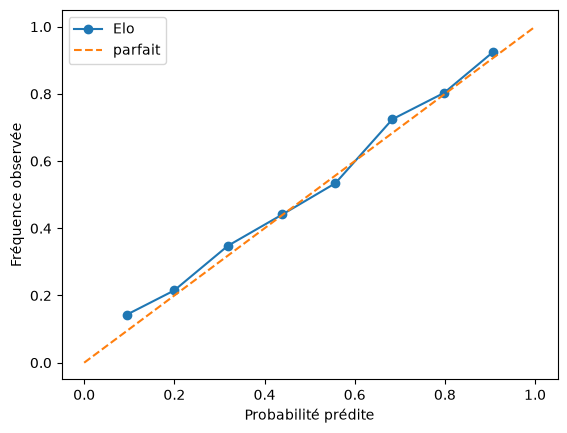

In [40]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

frac, mean_p = calibration_curve(test["blue_win"], test["p_elo"], n_bins=8)
plt.plot(mean_p, frac, marker="o", label="Elo")
plt.plot([0, 1], [0, 1], "--", label="parfait")
plt.xlabel("Probabilité prédite"); plt.ylabel("Fréquence observée")
plt.legend(); plt.show()

In [41]:
g.shape

(10232, 14)

In [42]:
print(g.shape)
print(g.groupby([g["date"].dt.year, "league"]).size().unstack(0).fillna(0).astype(int).to_string())

(10232, 14)
date    2023  2024  2025
league                  
CBLOL    242   263     0
EWC        0    19    33
FST        0     0    35
LCK      488   482   555
LCO      139   154     0
LCP        0     0   291
LCS      264   192     0
LEC      288   294   308
LJL      258   148   374
LLA      193   213     0
LPL      755   717   805
LTA        0     0    40
LTA N      0     0   214
LTA S      0     0   222
MSI       76    78    80
PCS      293   297   302
VCS      362   252   141
WLDs     137   132    96


In [43]:
for lg in ["LTA", "PCL", "PCS"]:
    sub = g[g["league"] == lg]
    print(lg, len(sub), sub["split"].value_counts().to_dict())
    print(sub["blue_team"].unique()[:8])
    print()

LTA 40 {}
<ArrowStringArray>
[  '100 Thieves',   'paiN Gaming',      'Leviatan',        'Cloud9',
          'LOUD', 'Isurus Estral',   'Team Liquid',      'FlyQuest']
Length: 8, dtype: str

PCL 0 {}
<ArrowStringArray>
[]
Length: 0, dtype: str

PCS 892 {'Spring': 313, 'Summer': 277, 'Split 2': 147, 'Split 1': 79, 'Split 3': 56}
<ArrowStringArray>
['CTBC Flying Oyster',          'PSG Talon',        'Dewish Team',
             'J Team',      'Frank Esports',           'Impunity',
  'Deep Cross Gaming',           'SEM9 WPE']
Length: 8, dtype: str



In [44]:
miss = g[g["blue_id"].isna() | g["red_id"].isna()]
print(miss["league"].value_counts().head(10))
print(miss[["blue_team", "red_team"]].head(10))

league
LJL    252
PCS     16
VCS      4
Name: count, dtype: int64
                     blue_team                  red_team
6861                    REJECT                We Can Win
6862                 Black Dog         VelbeliKaizokudan
6865      Spirit Quartz Gaming                 Night Cap
6866           Kareha Children                     Hands
6868                We Can Win                 Black Dog
6870                   BraVeLY  VeLocitY (Japanese Team)
6872                 Night Cap                     Hands
6873              VARREL YOUTH           Kareha Children
6876         VelbeliKaizokudan                We Can Win
6877  VeLocitY (Japanese Team)               RAYN Clocks


In [45]:
g["blue_key"] = g["blue_id"].fillna("name:" + g["blue_team"])
g["red_key"] = g["red_id"].fillna("name:" + g["red_team"])
print(g.groupby("blue_key")["blue_team"].nunique().sort_values(ascending=False).head(5))

blue_key
name:Bamboo Juice     1
name:Black Dog        1
name:BloomStorm       1
name:BraVeLY          1
name:Deltan Gaming    1
Name: blue_team, dtype: int64


In [46]:
import numpy as np
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score

g = g.sort_values("date").reset_index(drop=True)

def run_elo(g, K=20, bonus=25):
    ratings, out = {}, []
    for r in g.itertuples():
        rb, rr = ratings.get(r.blue_key, 1500), ratings.get(r.red_key, 1500)
        p = 1 / (1 + 10 ** (-(rb + bonus - rr) / 400))
        out.append(p)
        d = K * (r.blue_win - p)
        ratings[r.blue_key], ratings[r.red_key] = rb + d, rr - d
    return np.array(out)

val_mask = (g["date"] >= "2024-01-01") & (g["date"] < "2025-01-01")
for K in [10, 20, 30, 40]:
    for bonus in [0, 25, 50]:
        p = run_elo(g, K, bonus)
        print(K, bonus, round(log_loss(g.loc[val_mask, "blue_win"], p[val_mask.values]), 4))

10 0 0.6215
10 25 0.6193
10 50 0.6217
20 0 0.6114
20 25 0.6089
20 50 0.6109
30 0 0.6102
30 25 0.6074
30 50 0.6093
40 0 0.612
40 25 0.6092
40 50 0.6108


In [47]:
K_BEST, BONUS_BEST = 30, 25   # à modifier selon ta grille

g["p_elo"] = run_elo(g, K_BEST, BONUS_BEST)
test = g[g["date"] >= "2025-01-01"]
y, p = test["blue_win"], test["p_elo"]
print("Parties test :", len(test))
print("Log loss :", round(log_loss(y, p), 4))
print("Brier :", round(brier_score_loss(y, p), 4))
print("Accuracy :", round(accuracy_score(y, p > 0.5), 3))

Parties test : 3496
Log loss : 0.6252
Brier : 0.2177
Accuracy : 0.647


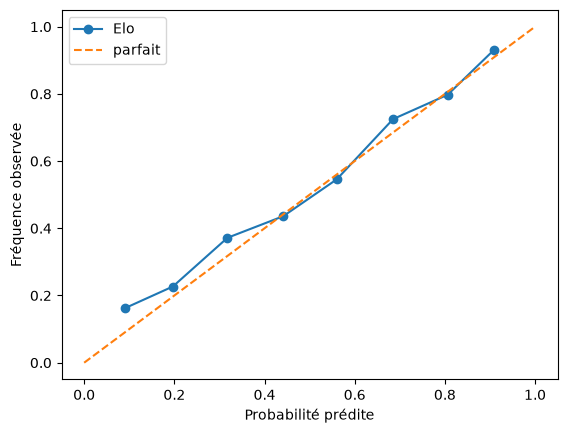

In [48]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

frac, mean_p = calibration_curve(test["blue_win"], test["p_elo"], n_bins=8)
plt.plot(mean_p, frac, marker="o", label="Elo")
plt.plot([0, 1], [0, 1], "--", label="parfait")
plt.xlabel("Probabilité prédite"); plt.ylabel("Fréquence observée")
plt.legend(); plt.show()

In [49]:
K_BEST

30

In [50]:
BONUS_BEST

25

In [51]:
assert g["gameid"].is_unique, "gameid en double"
assert "PCL" not in g["league"].unique(), "la PCL est encore là"
assert g["date"].is_monotonic_increasing, "g n'est pas triée par date"
assert g[["blue_key", "red_key"]].notna().all().all(), "clés manquantes"
assert g["blue_win"].isin([0, 1]).all(), "cible invalide"

print("Contrôles OK")
print("Parties :", len(g), "| période :", g["date"].min(), "->", g["date"].max())
print("Taux victoire bleu :", round(g["blue_win"].mean(), 3))
print("Parties test (variable 'test') :", len(test))

Contrôles OK
Parties : 10232 | période : 2023-01-14 07:23:06 -> 2025-11-09 11:31:30
Taux victoire bleu : 0.529
Parties test (variable 'test') : 3496


In [52]:
from collections import defaultdict, deque

def build_features(g, K=20, bonus=25):
    ratings = {}
    hist = defaultdict(lambda: deque(maxlen=10))
    last_date = {}
    rows = []
    for r in g.itertuples():
        b, rd = r.blue_key, r.red_key
        rb, rr = ratings.get(b, 1500), ratings.get(rd, 1500)
        hb, hr = list(hist[b]), list(hist[rd])
        rows.append({
            "elo_diff": rb + bonus - rr,
            "form5_blue": np.mean(hb[-5:]) if hb else np.nan,
            "form5_red": np.mean(hr[-5:]) if hr else np.nan,
            "n_blue": len(hb), "n_red": len(hr),
            "rest_blue": (r.date - last_date[b]).days if b in last_date else np.nan,
            "rest_red": (r.date - last_date[rd]).days if rd in last_date else np.nan,
        })
        p = 1 / (1 + 10 ** (-(rb + bonus - rr) / 400))
        d = K * (r.blue_win - p)
        ratings[b], ratings[rd] = rb + d, rr - d
        hist[b].append(r.blue_win); hist[rd].append(1 - r.blue_win)
        last_date[b] = last_date[rd] = r.date
    return pd.DataFrame(rows, index=g.index)

feat = build_features(g, K_BEST, BONUS_BEST)
data = pd.concat([g, feat], axis=1)
print(data[["date", "blue_team", "red_team", "elo_diff", "form5_blue", "n_blue"]].tail(5))
print(data[["n_blue", "n_red"]].head(3))

                     date   blue_team    red_team   elo_diff  form5_blue  \
10227 2025-11-09 07:32:16  KT Rolster          T1 -12.697000         0.8   
10228 2025-11-09 08:32:00  KT Rolster          T1 -41.601140         0.6   
10229 2025-11-09 09:39:12          T1  KT Rolster  58.026078         0.8   
10230 2025-11-09 10:39:17          T1  KT Rolster  23.061775         0.6   
10231 2025-11-09 11:31:30  KT Rolster          T1  -1.073381         0.6   

       n_blue  
10227      10  
10228      10  
10229      10  
10230      10  
10231      10  
   n_blue  n_red
0       0      0
1       1      1
2       2      2


In [53]:
from sklearn.linear_model import LogisticRegression

cols = ["elo_diff", "form5_blue", "form5_red", "rest_blue", "rest_red"]
ok = (data["n_blue"] >= 5) & (data["n_red"] >= 5)
train_lr = data[ok & (data["date"] >= "2023-07-01") & (data["date"] < "2025-01-01")].copy()
test_lr = data[ok & (data["date"] >= "2025-01-01")].copy()

for d_ in (train_lr, test_lr):
    d_[["rest_blue", "rest_red"]] = d_[["rest_blue", "rest_red"]].clip(upper=30)

model = LogisticRegression(max_iter=1000)
model.fit(train_lr[cols], train_lr["blue_win"])
p_lr = model.predict_proba(test_lr[cols])[:, 1]

print("Parties test :", len(test_lr))
print("Elo seul     :", round(log_loss(test_lr["blue_win"], test_lr["p_elo"]), 4))
print("Reg. logist. :", round(log_loss(test_lr["blue_win"], p_lr), 4))

Parties test : 3301
Elo seul     : 0.6233
Reg. logist. : 0.6223


In [54]:
rng = np.random.default_rng(0)
y = test_lr["blue_win"].values
pe, pl = test_lr["p_elo"].values, p_lr
diffs = []
for _ in range(1000):
    i = rng.integers(0, len(y), len(y))
    diffs.append(log_loss(y[i], pl[i]) - log_loss(y[i], pe[i]))
print("Diff moyenne :", round(np.mean(diffs), 4))
print("IC 95 % :", np.percentile(diffs, [2.5, 97.5]).round(4))

Diff moyenne : -0.0009
IC 95 % : [-0.0039  0.002 ]


In [55]:
print(K_BEST, BONUS_BEST)

30 25


In [56]:
print("K utilisé :", K_BEST, BONUS_BEST)
print("Elo seul (test 2025) :", round(log_loss(g[g['date'] >= '2025-01-01']['blue_win'],
                                               g[g['date'] >= '2025-01-01']['p_elo']), 4))
print(data[["elo_diff"]].tail(3))

K utilisé : 30 25
Elo seul (test 2025) : 0.6252
        elo_diff
10229  58.026078
10230  23.061775
10231  -1.073381


In [57]:
INTL = ["MSI", "WLDs", "FST", "EWC"]
recent = data[data["date"] >= "2025-01-01"]
intl = recent[recent["league"].isin(INTL)]
nat = recent[~recent["league"].isin(INTL)]
print("Parties internationales :", len(intl), "| nationales :", len(nat))
print("Log loss Elo (international) :", round(log_loss(intl["blue_win"], intl["p_elo"]), 4))
print("Log loss Elo (national)      :", round(log_loss(nat["blue_win"], nat["p_elo"]), 4))

Parties internationales : 244 | nationales : 3252
Log loss Elo (international) : 0.6773
Log loss Elo (national)      : 0.6213


In [58]:
from collections import defaultdict

INTL = ["MSI", "WLDs", "FST", "EWC"]
REGION = {"LCS": "NA", "LTA N": "NA", "LLA": "SA", "CBLOL": "SA", "LTA S": "SA"}
# les autres ligues gardent leur propre nom comme région

def run_elo_league(g, K=30, bonus=25, K_lg=5):
    ratings, offs, home, out = {}, defaultdict(float), {}, []
    for r in g.itertuples():
        b, rd = r.blue_key, r.red_key
        rb, rr = ratings.get(b, 1500), ratings.get(rd, 1500)
        if r.league in INTL:
            hb, hr = home.get(b), home.get(rd)
            ob = offs[hb] if hb else 0.0
            orr = offs[hr] if hr else 0.0
            p = 1 / (1 + 10 ** (-(rb + ob + bonus - rr - orr) / 400))
            out.append(p)
            e = K_lg * (r.blue_win - p)      # mise à jour APRÈS la prédiction
            if hb: offs[hb] += e
            if hr: offs[hr] -= e
        else:
            p = 1 / (1 + 10 ** (-(rb + bonus - rr) / 400))
            out.append(p)
            d = K * (r.blue_win - p)
            ratings[b], ratings[rd] = rb + d, rr - d
            reg = REGION.get(r.league, r.league)
            home[b] = home[rd] = reg
    return np.array(out)

# Choix de K_lg sur 2024 (validation), sans toucher à 2025
val = (g["date"] >= "2024-01-01") & (g["date"] < "2025-01-01")
val_intl = val & g["league"].isin(INTL)
for K_lg in [0, 2, 5, 10, 20]:
    p = run_elo_league(g, 30, 25, K_lg)
    print(K_lg,
          "| intl 2024 :", round(log_loss(g.loc[val_intl, "blue_win"], p[val_intl.values]), 4),
          "| tout 2024 :", round(log_loss(g.loc[val, "blue_win"], p[val.values]), 4))

0 | intl 2024 : 0.7533 | tout 2024 : 0.6094
2 | intl 2024 : 0.7379 | tout 2024 : 0.6083
5 | intl 2024 : 0.7192 | tout 2024 : 0.607
10 | intl 2024 : 0.698 | tout 2024 : 0.6055
20 | intl 2024 : 0.6773 | tout 2024 : 0.604


In [59]:
for K_lg in [20, 30, 40, 60, 80]:
    p = run_elo_league(g, 30, 25, K_lg)
    print(K_lg,
          "| intl 2024 :", round(log_loss(g.loc[val_intl, "blue_win"], p[val_intl.values]), 4),
          "| tout 2024 :", round(log_loss(g.loc[val, "blue_win"], p[val.values]), 4))

20 | intl 2024 : 0.6773 | tout 2024 : 0.604
30 | intl 2024 : 0.6709 | tout 2024 : 0.6036
40 | intl 2024 : 0.671 | tout 2024 : 0.6036
60 | intl 2024 : 0.6789 | tout 2024 : 0.6042
80 | intl 2024 : 0.6902 | tout 2024 : 0.605


In [61]:
K_LG_BEST = 20   # à modifier selon l'étape 1

g["p_elo_lg"] = run_elo_league(g, 30, 25, K_LG_BEST)

t25 = g[g["date"] >= "2025-01-01"]
i25 = t25[t25["league"].isin(INTL)]
n25 = t25[~t25["league"].isin(INTL)]

for nom, d in [("tout 2025", t25), ("international", i25), ("national", n25)]:
    print(nom, len(d),
          "| Elo :", round(log_loss(d["blue_win"], d["p_elo"]), 4),
          "| Elo + ligues :", round(log_loss(d["blue_win"], d["p_elo_lg"]), 4))

# Bootstrap sur l'ensemble de 2025
rng = np.random.default_rng(0)
y = t25["blue_win"].values
a, b = t25["p_elo_lg"].values, t25["p_elo"].values
diffs = []
for _ in range(1000):
    i = rng.integers(0, len(y), len(y))
    diffs.append(log_loss(y[i], a[i]) - log_loss(y[i], b[i]))
print("Diff moyenne :", round(np.mean(diffs), 4), "| IC 95 % :", np.percentile(diffs, [2.5, 97.5]).round(4))


tout 2025 3496 | Elo : 0.6252 | Elo + ligues : 0.6225
international 244 | Elo : 0.6773 | Elo + ligues : 0.6523
national 3252 | Elo : 0.6213 | Elo + ligues : 0.6202
Diff moyenne : -0.0028 | IC 95 % : [-0.0057  0.0004]
